<a href="https://colab.research.google.com/github/Adhira-Deogade/pytorch-learnings/blob/main/notebooks/sd/toy_example_swissroll.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install smalldiffusion

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from smalldiffusion import (
    TimeInputMLP,
    ScheduleLogLinear,
    samples,
    Swissroll,
    training_loop
)

In [4]:
# Plot dataset
def plot_batch(batch):
  batch = batch.cpu().numpy()
  # print(batch)
  batch_x, batch_y = batch[:,0], batch[:,1]
  # print(batch_x)
  # print(batch_y)
  plt.scatter(batch_x, batch_y, marker='.')


In [5]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

In [6]:
# Load and plot 2D data from SwissRoll dataset
dataset = Swissroll(np.pi/2, 5*np.pi, 100)
loader = DataLoader(dataset, batch_size=4096)
# plot_batch(next(iter(loader)))

In [7]:
print(len(dataset))

100


In [8]:
print(dataset[0])

tensor([-4.3711e-09,  1.0000e-01])


In [9]:
print(dataset[0].shape)

torch.Size([2])


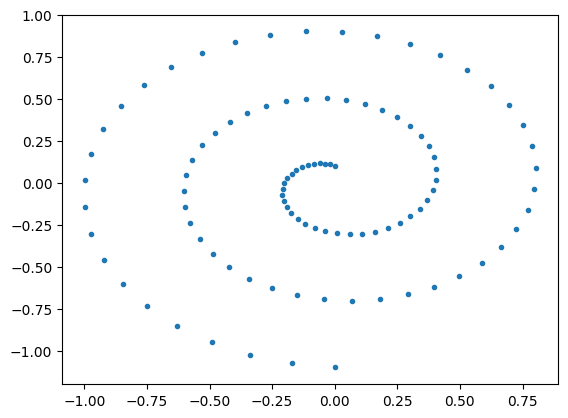

In [10]:
plot_batch(next(iter(loader)))

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2685131370.py:6: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sigma_t$")


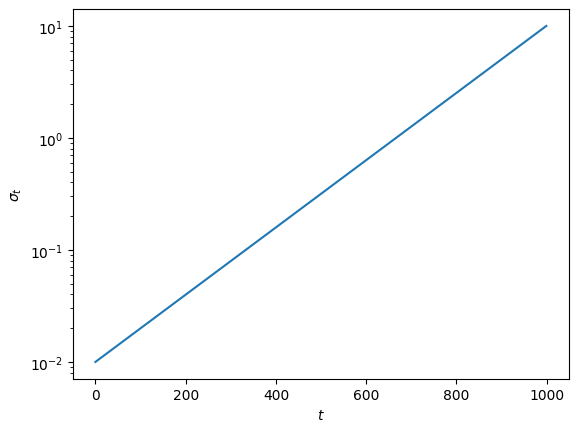

In [11]:
# Schedule
# Using a log-linear schedule
schedule = ScheduleLogLinear(1000, sigma_min=0.01, sigma_max=10)
plt.plot(schedule.sigmas)
plt.xlabel("$t$")
plt.ylabel("$\sigma_t$")
plt.yscale("log")

In [12]:
# Define a multi-layer perceptron, no U-Net so far (No convolution layers required)
model = TimeInputMLP(
    hidden_dims=(
      16,
      128,
      128,
      128,
      128,
      16
    )
)
print(model)


TimeInputMLP(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=16, out_features=128, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): GELU(approximate='none')
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): GELU(approximate='none')
    (10): Linear(in_features=128, out_features=16, bias=True)
    (11): GELU(approximate='none')
    (12): Linear(in_features=16, out_features=2, bias=True)
  )
)


In [ ]:
# Training model
trainer = training_loop(
    loader,
    model,
    schedule,
    epochs=15000,
    lr=1e-3
)
losses = [
    ns.loss.item() for ns in trainer
]

 23%|██▎       | 3440/15000 [00:19<01:01, 187.38it/s]